In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
partidos_df : pd.DataFrame = pd.read_csv("https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv")


In [ ]:

teams = pd.concat([partidos_df["1"], partidos_df["2"]]).drop_duplicates()
print(teams.size)

32


In [ ]:
partidos_df["2"].size

64

In [ ]:
partidos_df["group"].drop_duplicates().size - 7
#puse -7 porque hay group a ... group h entonces reste 7. Tambien conte 3 y 4 puesto

6

In [ ]:
partidos_df["attendance"].mean()*100

np.float64(5319143.75)

In [ ]:
goles : int = partidos_df["1_goals"] - partidos_df["2_goals"]
goles.abs().max()

7

In [ ]:
team1 = partidos_df.groupby("1")["1_panelties_scored"].sum()
team2 = partidos_df.groupby("2")["2_panelties_scored"].sum()
teams = pd.concat([team1,team2])
teams.idxmax()

'ARGENTINA'

In [ ]:
team1 = partidos_df.groupby("2")["1_panelties_scored"].sum()
team2 = partidos_df.groupby("1")["2_panelties_scored"].sum()
teams = pd.concat([team1,team2])
teams.idxmax()

'FRANCE'

### PARTE 2

In [5]:
equipo : str = "ARGENTINA"
# local en realidad es los partidos que jugo siendo equipo 1
partidos_df.groupby('1')["1"].count().loc[equipo]

np.int64(5)

In [ ]:
partidos_df.groupby('2')["2"].count().loc[equipo]

np.int64(2)

In [ ]:
partidosJugados = partidos_df.groupby('2')["2"].count().loc[equipo] + partidos_df.groupby('1')["1"].count().loc[equipo]
print(partidosJugados)

7


In [ ]:
golesArg = partidos_df[partidos_df['1'] == equipo]["1_goals"].sum() + partidos_df[partidos_df['2'] == equipo]["2_goals"].sum()
print(golesArg)

15


In [ ]:
promedioGolArg = (golesArg / partidosJugados)
print(promedioGolArg)

2.142857142857143


In [ ]:
gano_local = (partidos_df['1'] == equipo) & (partidos_df['1_goals'] > partidos_df['2_goals'])

gano_visitante = (partidos_df['2'] == equipo) & (partidos_df['2_goals'] > partidos_df['1_goals'])
gano = pd.concat([gano_local, gano_visitante])

print(gano.sum())

4


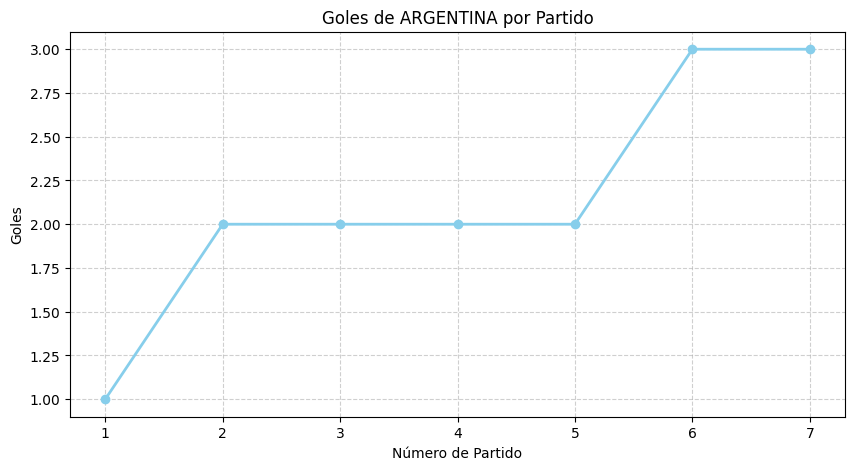

In [6]:
condiciones = [partidos_df['1'] == equipo, partidos_df['2'] == equipo]
opciones = [partidos_df['1_goals'], partidos_df['2_goals']]
partidos_df['goles_arg'] = np.select(condiciones, opciones, default=np.nan)

partidos_arg = partidos_df.dropna(subset=['goles_arg']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(partidos_arg.index + 1, partidos_arg['goles_arg'], marker='o', color='skyblue', linewidth=2)

ax.set_title(f'Goles de {equipo} por Partido')
ax.set_xlabel('Número de Partido')
ax.set_ylabel('Goles')
ax.set_xticks(range(1, len(partidos_arg) + 1))
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

### **Parte 3**

In [8]:
goles_local = partidos_df.groupby('1')['1_goals'].sum()
goles_visita = partidos_df.groupby('2')['2_goals'].sum()
total_goles = goles_local.add(goles_visita, fill_value=0).sort_values(ascending=False)
equipos = total_goles.index
goles = total_goles.values
print(equipos)
print(goles)

Index(['FRANCE', 'ARGENTINA', 'ENGLAND', 'PORTUGAL', 'NETHERLANDS', 'SPAIN',
       'CROATIA', 'BRAZIL', 'MOROCCO', 'GERMANY', 'SERBIA', 'SWITZERLAND',
       'KOREA REPUBLIC', 'SENEGAL', 'GHANA', 'JAPAN', 'CAMEROON', 'IRAN',
       'ECUADOR', 'AUSTRALIA', 'UNITED STATES', 'SAUDI ARABIA', 'POLAND',
       'COSTA RICA', 'URUGUAY', 'MEXICO', 'CANADA', 'BELGIUM', 'DENMARK',
       'QATAR', 'TUNISIA', 'WALES'],
      dtype='object', name='1')
[16 15 13 12 10  9  8  8  6  6  5  5  5  5  5  5  4  4  4  4  3  3  3  3
  2  2  2  1  1  1  1  1]


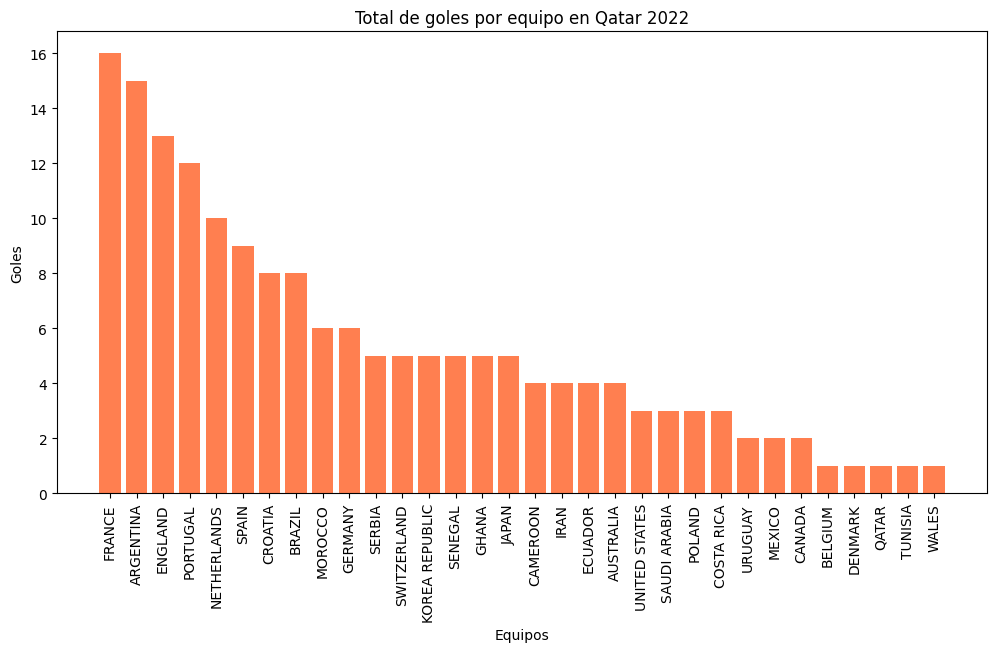

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(equipos, goles, color='coral')
ax.set_title('Total de goles por equipo en Qatar 2022')
ax.set_xlabel('Equipos')
ax.set_ylabel('Goles')
plt.xticks(rotation=90)
plt.show()

In [11]:
total_goles.idxmax()

'FRANCE'

In [13]:
partidos_df['diferencia_goles'] = (partidos_df['1_goals'] - partidos_df['2_goals']).abs()
print(partidos_df[['match_no', '1', '2', 'diferencia_goles']])

    match_no              1             2  diferencia_goles
0          1          QATAR       ECUADOR                 2
1          2        ENGLAND          IRAN                 4
2          3        SENEGAL   NETHERLANDS                 2
3          4  UNITED STATES         WALES                 0
4          5      ARGENTINA  SAUDI ARABIA                 1
..       ...            ...           ...               ...
59        60        ENGLAND        FRANCE                 1
60        61      ARGENTINA       CROATIA                 3
61        62         FRANCE       MOROCCO                 2
62        63        CROATIA       MOROCCO                 1
63        64      ARGENTINA        FRANCE                 0

[64 rows x 4 columns]


In [15]:
partidos_df['ganador'] = 'Empate'
partidos_df.loc[partidos_df['1_goals'] > partidos_df['2_goals'], 'ganador'] = partidos_df['1']
partidos_df.loc[partidos_df['2_goals'] > partidos_df['1_goals'], 'ganador'] = partidos_df['2']
empates = partidos_df['1_goals'] == partidos_df['2_goals']
partidos_df.loc[empates & (partidos_df['1_panelties_scored'] > partidos_df['2_panelties_scored']), 'ganador'] = partidos_df['1']
partidos_df.loc[empates & (partidos_df['2_panelties_scored'] > partidos_df['2_panelties_scored']), 'ganador'] = partidos_df['2']

print(partidos_df[['match_no', '1', '2', 'ganador']])

    match_no              1             2       ganador
0          1          QATAR       ECUADOR       ECUADOR
1          2        ENGLAND          IRAN       ENGLAND
2          3        SENEGAL   NETHERLANDS   NETHERLANDS
3          4  UNITED STATES         WALES        Empate
4          5      ARGENTINA  SAUDI ARABIA  SAUDI ARABIA
..       ...            ...           ...           ...
59        60        ENGLAND        FRANCE        FRANCE
60        61      ARGENTINA       CROATIA     ARGENTINA
61        62         FRANCE       MOROCCO        FRANCE
62        63        CROATIA       MOROCCO       CROATIA
63        64      ARGENTINA        FRANCE        Empate

[64 rows x 4 columns]


In [16]:
g_local = partidos_df.groupby(['group', '1'])['1_goals'].sum().reset_index()
g_visita = partidos_df.groupby(['group', '2'])['2_goals'].sum().reset_index()

g_local.columns = ['fase', 'equipo', 'goles']
g_visita.columns = ['fase', 'equipo', 'goles']

goles_fase = pd.concat([g_local, g_visita]).groupby(['fase', 'equipo']).sum().reset_index()
max_fase = goles_fase.sort_values('goles', ascending=False).drop_duplicates('fase')

print(max_fase)

                        fase       equipo  goles
6                    Group B      ENGLAND      9
21                   Group E        SPAIN      9
16                   Group D       FRANCE      6
55               Round of 16     PORTUGAL      6
32                   Group H     PORTUGAL      6
3                    Group A  NETHERLANDS      5
28                   Group G       SERBIA      5
10                   Group C    ARGENTINA      5
24                   Group F      CROATIA      4
0                      Final    ARGENTINA      3
60                Semi-Final    ARGENTINA      3
42             Quarter-final  NETHERLANDS      2
34  Play-off for third place      CROATIA      2


### **Parte 4**

Partidos por estadio.


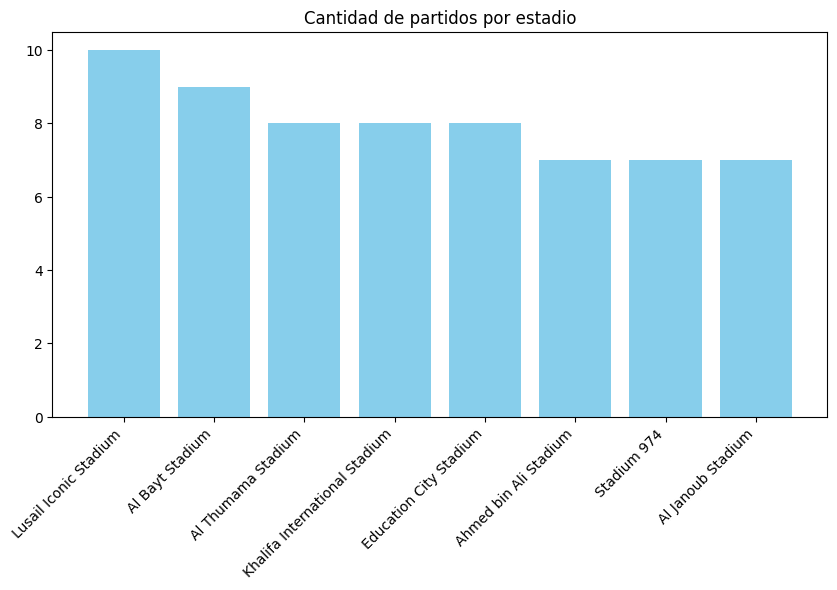

In [17]:
partidos_estadio = partidos_df['venue'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(partidos_estadio.index, partidos_estadio.values, color='skyblue')
ax.set_title('Cantidad de partidos por estadio')
plt.xticks(rotation=45, ha='right')
plt.show()